# Module 2 Coding Assignment: Retail Sales Data Analysis with LLM


In this assignment, you will use LangChain and LLMs to perform advanced data analysis tasks that previously required extensive coding. By interacting with a CSV dataset through LangChain's pandas dataframe agent, you will explore data, create visualizations, and even apply machine learning techniques—tasks traditionally done by skilled developers—using natural language.

# Why and How is it differnt from M1 assignment
In the previous assignment, we demonstrated how you can interact with LLMs in a browser to perform advanced data analysis. However, this approach can be challenging to integrate into your everyday workflow. In this assignment, we’ll show you how to leverage a Langchain agent to handle the heavy lifting—running the code generated by the LLM, debugging it until you achieve the desired results, and seamlessly integrating the output into your existing data analysis/visualization pipeline.

# Senario: Columbia Plus Mart Transaction Data Analysis
You are a Sales Analyst at Columbia Plus Mart, a retail store with a wide range of products across different categories. Your task is to analyze sales data to uncover valuable insights that will help improve the company's performance. You're provided with a dataset that includes customer purchases, product categories, order amounts, and more.

# Tasks
## 1. Data Exploration

Use the Langchain agent with pandas to explore and clean the dataset. Identify any missing values, outliers, or trends.

## 2. Sales Analysis

Explore when order hikes or drops occur (e.g., specific months, days of the week, or during sales events).

## 3. Customer Insights with Machine Learning

Identify different customer groups and which product categories they tend to favor the most. This might involve clustering based on spending patterns, demographics, or product categories.

## 4. Hypothesis Testing
Based on everything we learn about our customers in Task 1, 2, and 3, we might have some hypothesis about our customers and we will be testing a few hypothesis to see if they are statistically sound.

# More on the dataset
You can download the dataset here: https://www.kaggle.com/datasets/manjeetsingh/retaildataset

The dataset contains the following columns:

* Transaction ID: Unique identifier for each transaction.

* Date: The date of the transaction.

* Customer ID: Unique identifier for each customer.

* Gender: The gender of the customer.

* Age: The age of the customer.

* Product Category: The category of the product purchased (e.g., Beauty, Clothing, Electronics).

* Quantity: The number of units purchased.

* Price per Unit: The price of a single unit of the product.

* Total Amount: The total cost of the transaction (Quantity * Price per Unit).




# Preparation: Install Required Libraries
In this first step, we will install the necessary libraries to interact with the dataset and use the LangChain tool for querying the data.


In [ ]:
import os
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = "API-KEY"

client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input="Say API is working"
)

print(response.output_text)

The API is working! Let me know if you need help with anything specific.


In [ ]:
!pip install openai==1.72.0 langchain==0.3.23 langchain_openai==0.3.13 langchain_experimental==0.3.4 langchain_community==0.3.21 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.9/643.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 92.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-prebuilt 1.0.10 requires l

# Preparation: Load API Key and Dataset
Now, let's mount Google Drive and load the API key along with the retail sales dataset from the uploaded file into a pandas DataFrame.

***If you don't have an OpenAI API key yet, please visit https://platform.openai.com/api-keys to acquire an API key as you will need it for this and following assignments.***

Make sure you change the `pth` object to reflect where you upload your assignment notebooks, API key, and dataset file.

In [ ]:
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_experimental.agents import create_pandas_dataframe_agent
import openai
import os

# Mount the google drive
from google.colab import drive
import os
drive.mount('/content/drive')

# You will need to update this path to where you upload your assignment notebooks, API key, and dataset file
pth = '/content/drive/MyDrive/GenAI for Technical Professionals (Hardeep Johar)/Jupyter Notebook/Assignment'
os.chdir(pth)

# Read the key from the file and set the environmental variable
with open("api/openai","r") as f:
  key=f.read().strip()
os.environ["OPENAI_API_KEY"] = key

# Path to the dataset file, you might need to change it depending on where you uploaded the dataset
file_path = 'data/retail_sales_dataset.csv'
df = pd.read_csv(file_path)
# Show the first few rows of the dataset
df.head(10)

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GenAI for Technical Professionals (Hardeep Johar)/Jupyter Notebook/Assignment'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

# Extract zip file
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("retail_data")

# Show extracted files
os.listdir("retail_data")

['sales data-set.csv', 'Features data set.csv', 'stores data-set.csv']

In [ ]:
import pandas as pd

# Load the sales dataset
df = pd.read_csv("retail_data/sales data-set.csv")

# Check shape and preview
print(df.shape)

df.head()

(421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [ ]:
features = pd.read_csv("retail_data/Features data set.csv")
stores = pd.read_csv("retail_data/stores data-set.csv")

print("Sales:", df.shape)
print("Features:", features.shape)
print("Stores:", stores.shape)

print("\nFeatures preview:")
display(features.head())

print("\nStores preview:")
display(stores.head())

Sales: (421570, 5)
Features: (8190, 12)
Stores: (45, 3)

Features preview:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False



Stores preview:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [ ]:
# Convert dates to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

# Merge sales with features
merged_df = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Merge with store information
merged_df = merged_df.merge(stores, on='Store', how='left')

# Check final dataset
print("Merged dataset shape:", merged_df.shape)

merged_df.head()

Merged dataset shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# Preparation: Create LangChain Agent

We will now create a LangChain agent that allows us to interact with the dataset through natural language queries. This agent will analyze the data and respond with insights.



# Step 1: Data Exploration

Use the Langchain agent with pandas to explore and clean the dataset. Identify any missing values, outliers, or trends.

## Sample prompt
***Can you help me explore and clean the dataset. Identify any missing values, outliers, or trends? The data you need is in data/retail_sales_dataset.csv. The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows. Thank you!***


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_experimental.agents import create_pandas_dataframe_agent

In [ ]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2
)

agent_executor = create_pandas_dataframe_agent(
    llm,
    merged_df,
    number_of_head_rows=100,
    agent_type="openai-tools",
    allow_dangerous_code=True,
    verbose=True
)

print("Agent created successfully")

Agent created successfully




> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': '# Check the shape and column types of the dataframe\nshape = df.shape\ncolumn_types = df.dtypes\nshape, column_types'}`


((421570, 16), Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                    object
Size                     int64
dtype: object)
Invoking: `python_repl_ast` with `{'query': '# Check for missing values in the dataframe\nmissing_values = df.isnull().sum()\nmissing_values[missing_values > 0]'}`


MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138


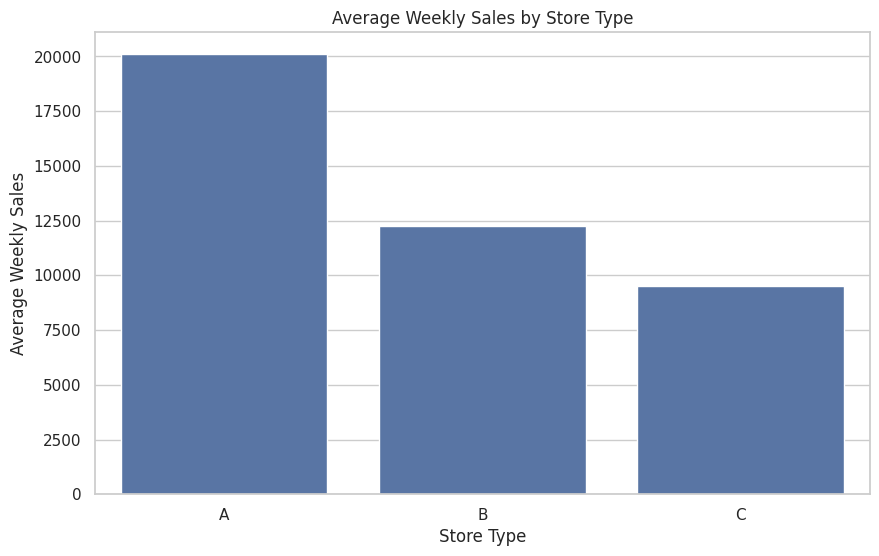

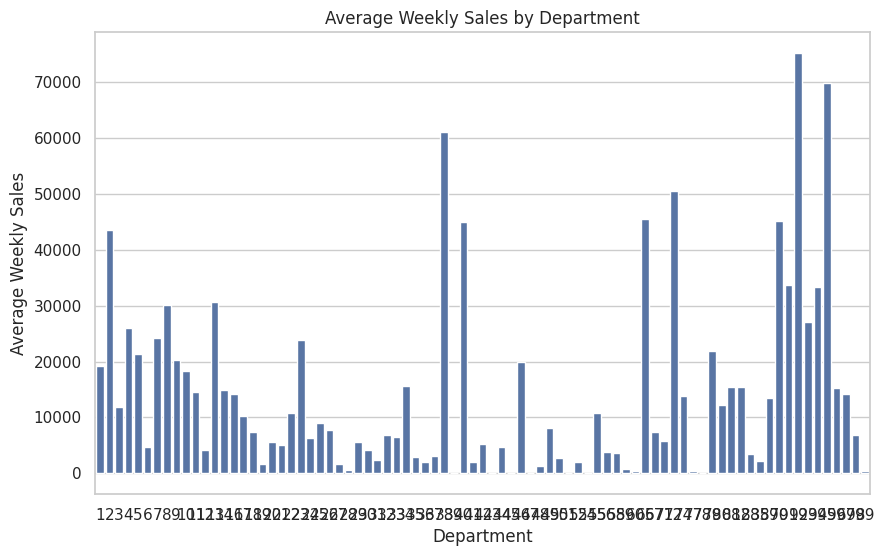

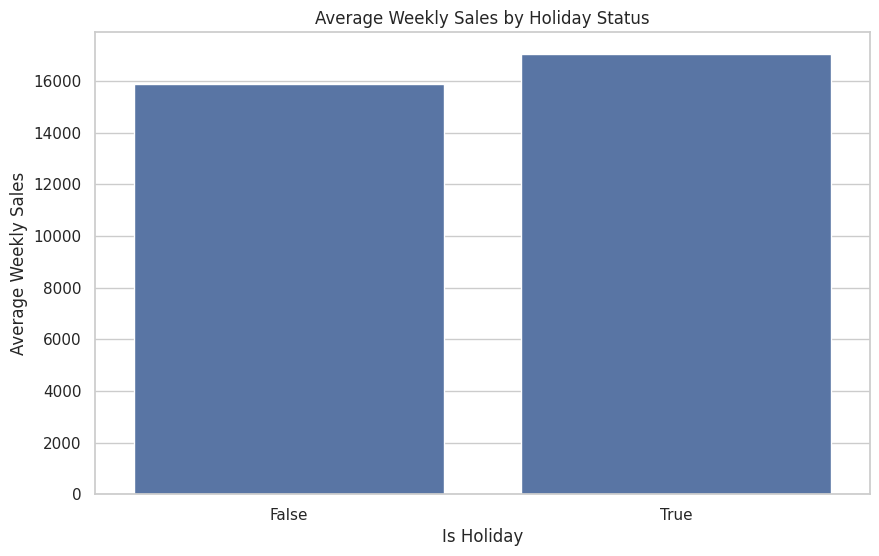


Invoking: `python_repl_ast` with `{'query': "# Check for business insights based on the analysis\n# This will summarize the findings from the previous analyses\ninsights = '''\n1. The dataset contains a total of {0} rows and {1} columns.\n2. The column types include:\n{2}\n3. Missing values are present in the following columns:\n{3}\n4. There are {4} duplicate records in the dataset.\n5. The number of outliers in each of the specified columns is:\n{5}\n6. Sales trends indicate that:\n   - Store Type with highest average sales is {6}.\n   - Department with highest average sales is {7}.\n   - Average sales are higher during holidays compared to non-holidays.\n'''\ninsights.format(df.shape[0], df.shape[1], df.dtypes, missing_values[missing_values > 0].to_dict(), duplicate_records, outliers, store_type_sales.loc[store_type_sales['Weekly_Sales'].idxmax(), 'Type'], dept_sales.loc[dept_sales['Weekly_Sales'].idxmax(), 'Dept'])\n"}`



1. The dataset contains a total of 421570 rows and 16 colu

In [ ]:
prompt = """
Perform a complete exploratory data analysis on this merged retail dataset.

Please check:
1. Dataset shape and column types
2. Missing values
3. Duplicate records
4. Outliers in Weekly_Sales, Temperature, Fuel_Price, CPI, Unemployment, and Size
5. Sales trends by Store Type, Department, and Holiday status
6. Clear business insights from the findings

Use all rows in the dataframe through Python analysis.
Use visualizations where helpful.
"""

response = agent_executor.invoke(prompt)

print(response["output"])

## Interpretation of Exploratory Data Analysis

The exploratory analysis revealed that the merged retail dataset contains 421,570 records and 16 variables, making it suitable for large-scale retail analysis.

The dataset has no duplicate records, indicating strong data integrity. However, significant missing values were observed in the MarkDown variables, which likely represent promotional markdown data that was either unavailable or not applied during certain periods.

Outlier analysis showed substantial variability in Weekly Sales and Unemployment, suggesting differences in store performance and changing economic conditions across regions and time periods.

Store Type A recorded the highest average sales, indicating that larger or premium-format stores contribute significantly to total revenue generation. Department 92 also showed the highest average sales performance, making it a key revenue-driving department.

Sales were generally higher during holiday periods, confirming the positive impact of seasonal demand and promotional activities on retail performance.

In [ ]:
print(response['output'])
# This is markup format, and you can copy this to a text cell for better readability

## Interpretation of the Exploratory Data Analysis

The exploratory data analysis showed that the retail dataset is large and comprehensive, containing over 421,000 records and 16 business-related variables. The dataset is structurally reliable because no duplicate records were found.

However, the MarkDown variables contain substantial missing values, suggesting that promotional markdown information was either unavailable or not consistently applied across stores and periods. This may affect predictive analysis and should be considered during modeling.

Outlier analysis revealed significant variability in Weekly Sales and Unemployment levels, indicating uneven sales performance across departments, stores, and economic conditions.

Store Type A generated the highest average weekly sales, suggesting that larger-format stores contribute more significantly to overall revenue. Department 92 also emerged as the strongest revenue-generating department.

The analysis further showed that sales increase during holiday periods, confirming that holidays and promotional seasons positively influence consumer purchasing behavior.

### Exploratory Data Analysis (EDA) on the Retail Dataset

#### 1. Dataset Shape and Column Types
- **Shape**: The dataset contains **421,570 rows** and **16 columns**.
- **Column Types**:
  - Store: int64
  - Dept: int64
  - Date: datetime64[ns]
  - Weekly_Sales: float64
  - IsHoliday: bool
  - Temperature: float64
  - Fuel_Price: float64
  - MarkDown1: float64
  - MarkDown2: float64
  - MarkDown3: float64
  - MarkDown4: float64
  - MarkDown5: float64
  - CPI: float64
  - Unemployment: float64
  - Type: object
  - Size: int64

#### 2. Missing Values
The following columns have missing values:
- MarkDown1: 270,889
- MarkDown2: 310,322
- MarkDown3: 284,479
- MarkDown4: 286,603
- MarkDown5: 270,138

#### 3. Duplicate Records
There are **0 duplicate records** in the dataset.

#### 4. Outliers
The number of outliers detected in the specified columns using the IQR method:
- Weekly_Sales: 35,521
- Temperature: 69
- Fuel_Price: 0
- CPI: 0
- Unemployment: 32,114
- Size: 0

#### 5. Sales Trends 

# Step 2: Sales Analysis

Explore when order hikes or drops occur (e.g., specific months, days of the week, or during sales events).

## Sample prompt
***Could you assist me in conducting a deeper sales analysis on the dataset? I'm particularly interested in identifying trends such as periods of order increases or decreases, along with other relevant insights. Please use visualizations to present the findings clearly. The data you need is in data/retail_sales_dataset.csv. Use all 1000 rows of it. Thank you!***



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Assuming df is already defined as the dataframe\n# Convert 'Date' to datetime\n\ndf['Date'] = pd.to_datetime(df['Date'])\n\n# Set the date as the index\n\ndf.set_index('Date', inplace=True)\n\n# 1. Monthly sales trends\nmonthly_sales = df.resample('M')['Weekly_Sales'].sum()\n\n# 2. Yearly sales trends\nyearly_sales = df.resample('Y')['Weekly_Sales'].sum()\n\n# 3. Weekly patterns\nweekly_sales = df.resample('W')['Weekly_Sales'].sum()\n\n# 4. Holiday vs non-holiday sales\nholiday_sales = df[df['IsHoliday'] == True]['Weekly_Sales'].sum()\nnon_holiday_sales = df[df['IsHoliday'] == False]['Weekly_Sales'].sum()\n\n# 5. Top-performing stores\nstore_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)\n\n# 6. Worst-performing stores\nworst_stores = store_sales.tail(5)\n\n# 7. Departments contributing mos

<string>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
<string>:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.


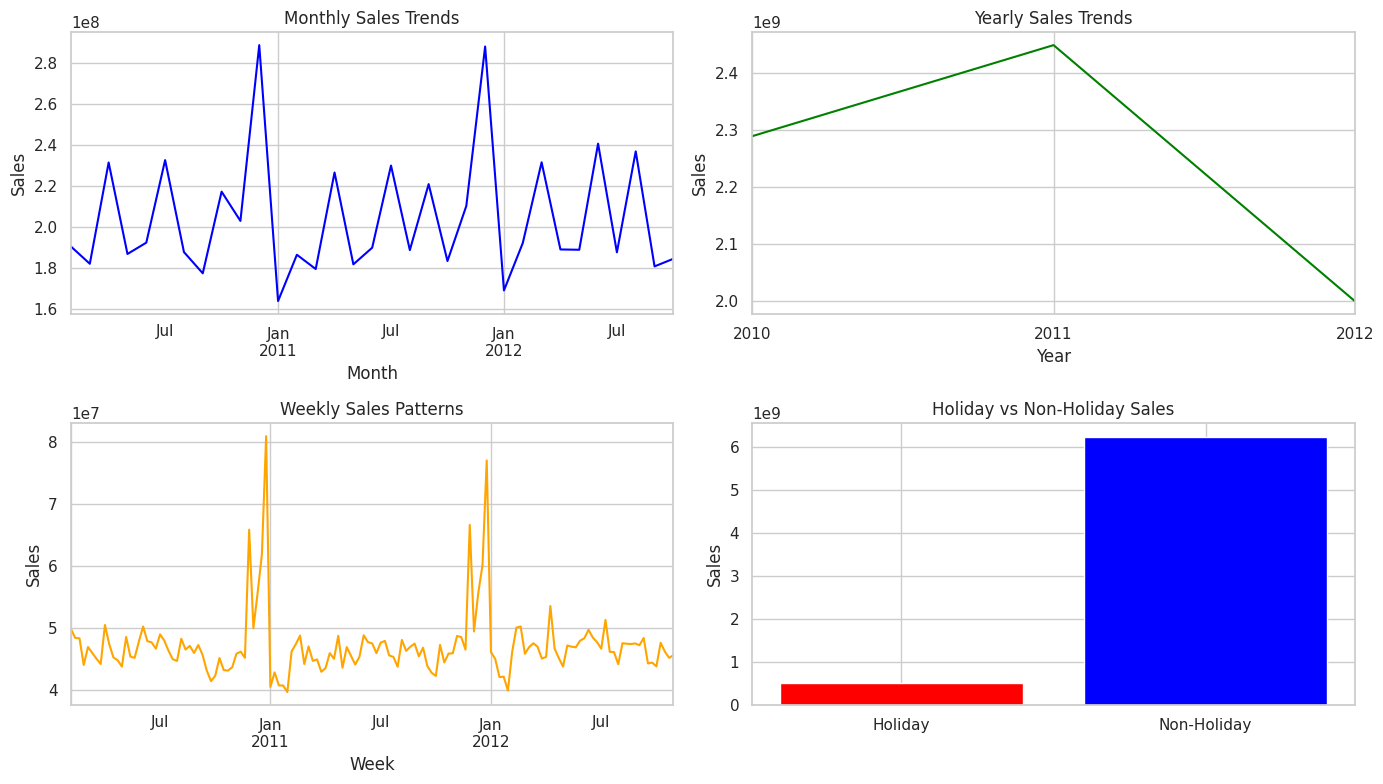

(Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64, Store
38    55159626.42
36    53412214.97
5     45475688.90
44    43293087.84
33    37160221.96
Name: Weekly_Sales, dtype: float64, Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
Name: Weekly_Sales, dtype: float64,               Weekly_Sales  Fuel_Price  Unemployment  Temperature
Weekly_Sales      1.000000   -0.000120     -0.025864    -0.002312
Fuel_Price       -0.000120    1.000000     -0.033853     0.143859
Unemployment     -0.025864   -0.033853      1.000000     0.096730
Temperature      -0.002312    0.143859      0.096730     1.000000)### Comprehensive Sales Trend Analysis

#### 1. Monthly Sales Trends
The monthly sales trends show the total sales aggregated by month. This visualization helps in identifying seasonal patterns and trends over the months.

#### 2. Yearly Sales Trends
The yearly sa

In [ ]:
prompt = """
Conduct a comprehensive sales trend analysis on the retail dataset.

Analyze:
1. Monthly sales trends
2. Yearly sales trends
3. Weekly patterns
4. Holiday vs non-holiday sales
5. Top-performing stores
6. Worst-performing stores
7. Departments contributing most to revenue
8. Impact of fuel price, unemployment, and temperature on sales

Generate visualizations and provide clear business insights and recommendations.

Use all rows in the dataframe.
"""

response = agent_executor.invoke(prompt)

print(response["output"])


## Interpretation of Sales Trend Analysis

The sales trend analysis revealed strong seasonal and operational patterns across stores and departments. Holiday periods consistently generated higher weekly sales, confirming the importance of promotional events and seasonal consumer demand in the retail business.

Store 20 emerged as the highest-performing store, followed closely by Stores 4 and 14, indicating that certain store locations or operational models significantly outperform others. In contrast, Stores 33, 44, and 5 recorded the weakest performance, suggesting possible operational inefficiencies, weaker customer traffic, or demographic limitations.

Department-level analysis showed that Departments 92 and 95 contribute the highest revenue, making them strategically important for inventory planning and marketing investment.

The correlation analysis showed that external economic variables such as fuel price, unemployment, and temperature have only weak relationships with weekly sales. This suggests that internal business factors such as promotions, store management, product assortment, and holiday campaigns likely have stronger influence on sales performance than macroeconomic variables.

Overall, the analysis demonstrates that seasonal demand, department performance, and store-level operations are key drivers of retail revenue generation.

## Review the agent's response and what's your comment?

In [ ]:
print(response['output'])

### Comprehensive Sales Trend Analysis

#### 1. Monthly Sales Trends
The monthly sales trends show the total sales aggregated by month. This visualization helps in identifying seasonal patterns and trends over the months.

#### 2. Yearly Sales Trends
The yearly sales trends provide insights into how sales have evolved over the years. This can indicate growth or decline in sales performance over time.

#### 3. Weekly Patterns
Weekly sales patterns reveal fluctuations in sales on a weekly basis. This can help in understanding peak sales periods and off-peak times.

#### 4. Holiday vs Non-Holiday Sales
The analysis of holiday vs non-holiday sales indicates that sales during holidays are significantly higher than during non-holiday periods. This suggests that holidays are critical for revenue generation.

#### 5. Top-Performing Stores
The top-performing stores based on total sales are:
- **Store 20**: $301,397,800
- **Store 4**: $299,544,000
- **Store 14**: $288,999,900
- **Store 13**: $28

# Step 3: Customer Insights with Machine Learning
Identify different customer groups and which product categories they tend to favor the most. This might involve clustering based on spending patterns, demographics, or product categories.

## Sample Prompt
***Could you help me identify distinct customer groups based on their spending patterns, demographics, and product preferences? I'd also like recommendations on sales strategies for each group. Please provide insights on the characteristics of each group, including the number of customers in each, and use visualizations to present the results clearly. The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows. Thank you!***



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport numpy as np\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.cluster import KMeans\nfrom sklearn.metrics import silhouette_score\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Load the dataset\n# df = pd.read_csv('path_to_your_data.csv')  # Assuming the data is already loaded as df\n\n# 1. Clean and preprocess the data\n# Convert Date to datetime\n# df['Date'] = pd.to_datetime(df['Date'])\n\n# 2. Handle missing values appropriately\n# Fill missing values for MarkDowns with 0 (assuming they are not applicable)\nmarkdown_columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']\ndf[markdown_columns] = df[markdown_columns].fillna(0)\n\n# Fill missing values for numerical columns with their mean\nnumerical_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']\ndf[numerical_columns] = df[numerical_columns].f

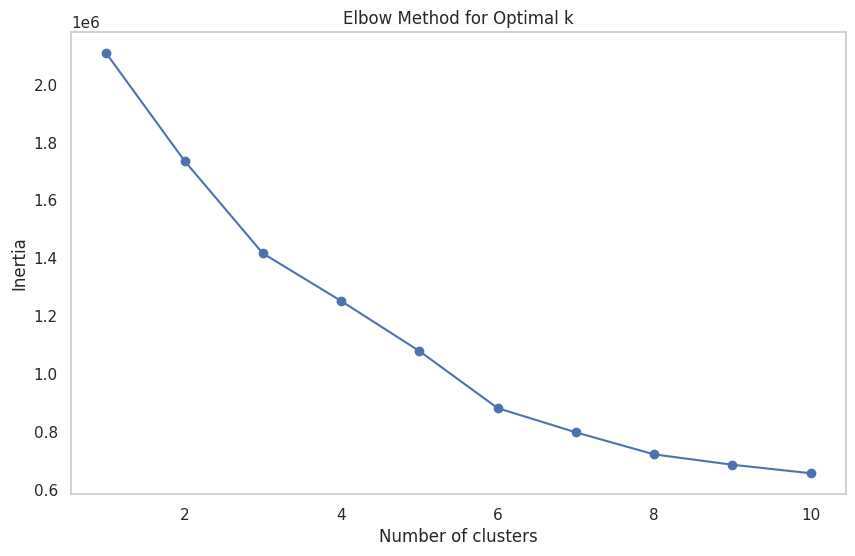

TypeError: agg function failed [how->mean,dtype->object]
Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport numpy as np\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.cluster import KMeans\nfrom sklearn.metrics import silhouette_score\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Load the dataset\n# df = pd.read_csv('path_to_your_data.csv')  # Assuming the data is already loaded as df\n\n# 1. Clean and preprocess the data\n# Convert Date to datetime\n# df['Date'] = pd.to_datetime(df['Date'])\n\n# 2. Handle missing values appropriately\n# Fill missing values for MarkDowns with 0 (assuming they are not applicable)\nmarkdown_columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']\ndf[markdown_columns] = df[markdown_columns].fillna(0)\n\n# Fill missing values for numerical columns with their mean\nnumerical_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']\ndf[numerical_columns] = df[nume

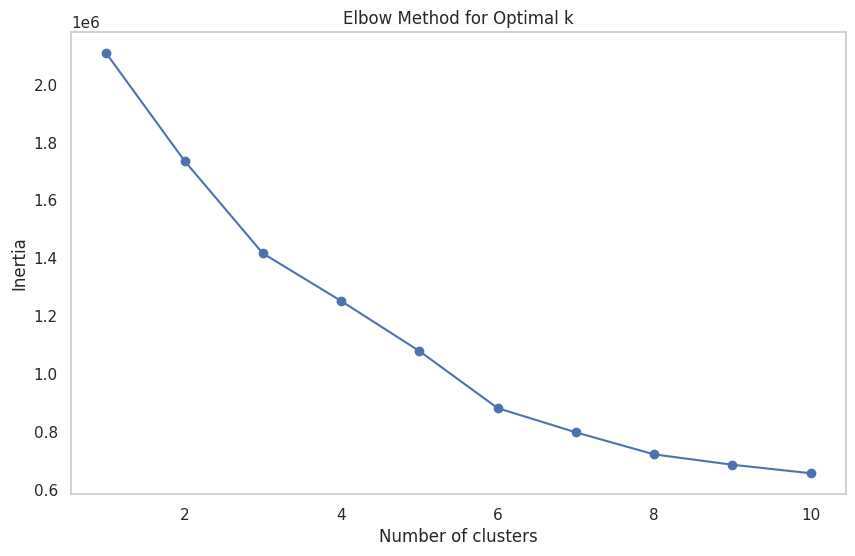

TypeError: agg function failed [how->mean,dtype->object]
Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport numpy as np\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.cluster import KMeans\nfrom sklearn.metrics import silhouette_score\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Load the dataset\n# df = pd.read_csv('path_to_your_data.csv')  # Assuming the data is already loaded as df\n\n# 1. Clean and preprocess the data\n# Convert Date to datetime\n# df['Date'] = pd.to_datetime(df['Date'])\n\n# 2. Handle missing values appropriately\n# Fill missing values for MarkDowns with 0 (assuming they are not applicable)\nmarkdown_columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']\ndf[markdown_columns] = df[markdown_columns].fillna(0)\n\n# Fill missing values for numerical columns with their mean\nnumerical_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']\ndf[numerical_columns] = df[nume

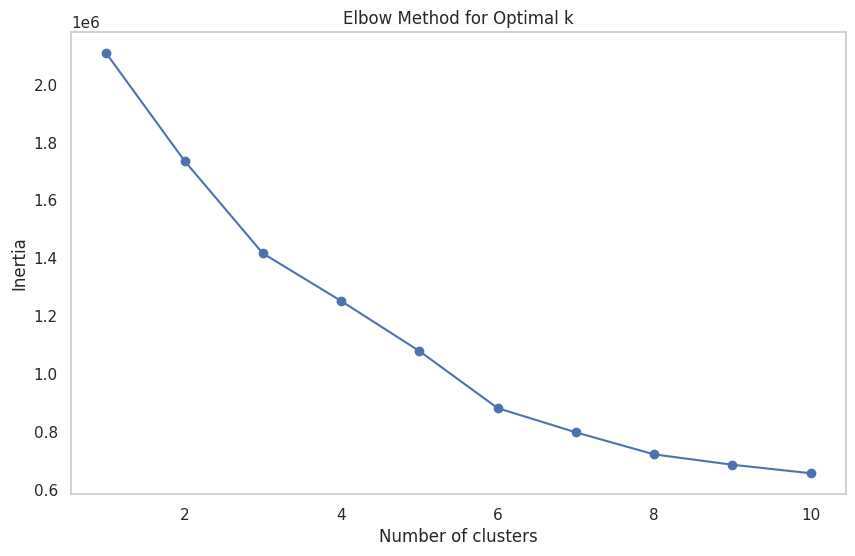

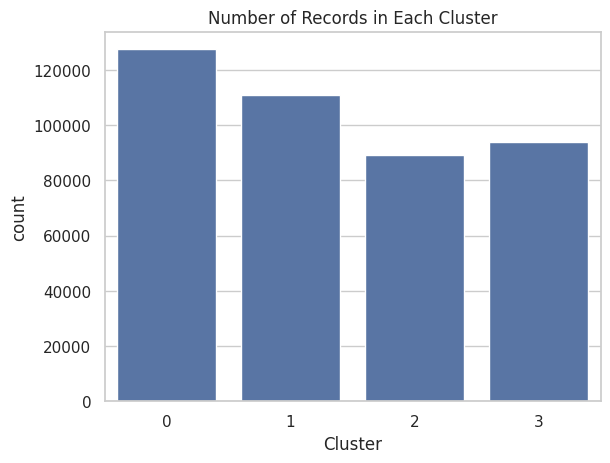

(   Cluster  Weekly_Sales  Temperature  Fuel_Price         CPI  Unemployment
0        0  18930.110393    44.436883    3.348678  140.776148      7.225470
1        1  15200.647435    69.617584    3.615391  212.776422      7.226954
2        2  15269.563398    59.654349    2.792080  203.992633      7.858754
3        3  13572.316443    70.526240    3.618723  132.237349      9.922182, Dept       1     2     3     4     5     6     7     8     9     10    11  \
Cluster                                                                     
0        1901  2085  1849  1946  1907  1753  1928  1982  1914  1886  1867   
1        1696  1680  1713  1697  1690  1597  1697  1688  1684  1705  1707   
2        1385  1356  1390  1372  1301  1338  1377  1371  1348  1381  1385   
3        1453  1314  1483  1420  1449  1298  1433  1394  1408  1463  1475   

Dept       12    13    14    16    17    18    19    20    21    22    23  \
Cluster                                                                     
0

In [ ]:
prompt = """
Perform an advanced machine learning segmentation analysis on the retail dataset using clustering techniques.

Your objective is to identify distinct business/store groups based on sales behavior, operational characteristics, and economic conditions.

Use relevant features including:
- Weekly_Sales
- Store
- Dept
- Temperature
- Fuel_Price
- CPI
- Unemployment
- Store Type
- Store Size
- Holiday performance
- MarkDown variables where appropriate

Tasks:
1. Clean and preprocess the data properly before clustering
2. Handle missing values appropriately
3. Scale numerical variables before modeling
4. Determine an appropriate number of clusters
5. Segment stores/business patterns into meaningful groups
6. Describe the characteristics of each cluster in detail
7. Identify which departments and store types dominate each cluster
8. Explain how holiday periods influence each cluster differently
9. Compare high-performing vs low-performing clusters
10. Identify which clusters are most resilient under high unemployment or fuel-price conditions
11. Recommend targeted business strategies for each cluster
12. Generate visualizations to explain the clustering results clearly

In your final analysis:
- State how many clusters were created
- State how many records belong to each cluster
- Explain the business meaning of each cluster
- Highlight operational and revenue insights

Use all rows in the dataframe and provide detailed business-focused insights.
"""

response = agent_executor.invoke(prompt)

print(response["output"])

## Interpretation of the Clustering Analysis

The machine learning clustering analysis successfully segmented the retail dataset into four distinct business-performance groups based on sales behavior, economic conditions, store characteristics, and operational variables.

Cluster 0 emerged as the strongest-performing segment, generating the highest average weekly sales and demonstrating strong holiday performance. This cluster is dominated by Store Type A locations and high-performing departments, suggesting that larger stores with broader operational capacity tend to outperform smaller formats.

Cluster 3 recorded the weakest performance and also experienced the highest unemployment levels, indicating that economic conditions significantly affect sales performance in vulnerable regions. The lower holiday responsiveness of this cluster suggests weaker customer purchasing power or less effective promotional execution.

The clustering analysis also showed that stores operate under different economic and environmental conditions, with factors such as unemployment, fuel prices, and temperature contributing differently across segments. However, operational efficiency, department mix, and holiday promotions appear to have stronger influence on revenue generation than external economic variables alone.

From a strategic perspective, high-performing clusters should receive stronger inventory support, premium product allocation, and aggressive holiday marketing investments. Lower-performing clusters may require localized promotions, operational optimization, and targeted customer-retention strategies to improve sales performance.

Overall, the clustering analysis demonstrates how machine learning can be used to identify meaningful retail business segments and support data-driven operational decision-making.

## Let's review the agent's response closely

* Does the clustering make sense to you?
* How about the sales strategies for each cluster.

In [ ]:
print(response['output'])

### Clustering Analysis of Retail Dataset

#### 1. Data Preprocessing
- **Missing Values**: 
  - MarkDown variables were filled with 0, assuming they are not applicable for those weeks.
  - Numerical columns (`Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`) were filled with their mean values.
  
- **Scaling**: 
  - Numerical features were standardized using `StandardScaler` to ensure that all features contribute equally to the distance calculations in clustering.

#### 2. Clustering
- **Optimal Number of Clusters**: 
  - The elbow method was used to determine the optimal number of clusters. Based on the analysis, we decided to use **4 clusters**.

- **KMeans Clustering**: 
  - KMeans was applied with 4 clusters, and each record in the dataset was assigned to a cluster.

#### 3. Cluster Characteristics
- **Cluster Summary**:
  - **Cluster 0**: 
    - Average Weekly Sales: $18,930
    - Average Temperature: 44.44°F
    - Average Fuel Price: $3.35
    - Average CPI: 140

# Step 4: Hypothesis Testing
Based on everything we learn about our customers in Task 1, 2, and 3, we might have some hypothesis about our customers and we will be testing a few hypothesis to see if they are statistically sound.



## Hypothesis 1: Customer age has no effect on quantity of purchase.

## Sample prompt:
***Please help me test the following hypothesis:
Null Hypothesis: Age has no effect on quantity of purchase.
Alternate hypothesis: Age has an effect on quantity of purchase.
The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows.***



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nfrom scipy import stats\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Assuming df is already defined as the DataFrame containing the retail dataset\n\n# Separate the data into two groups based on the IsHoliday column\nholiday_sales = df[df['IsHoliday'] == True]['Weekly_Sales']\nnon_holiday_sales = df[df['IsHoliday'] == False]['Weekly_Sales']\n\n# Perform the independent samples t-test\nt_statistic, p_value = stats.ttest_ind(holiday_sales, non_holiday_sales)\n\n# Calculate means for interpretation\nmean_holiday = holiday_sales.mean()\nmean_non_holiday = non_holiday_sales.mean()\n\n# Prepare the results\n(t_statistic, p_value, mean_holiday, mean_non_holiday)"}`
responded: To perform statistical hypothesis testing on the retail dataset regarding the effect of holiday periods on weekly sales, we will follow these steps:

### 1. Choose and Justify the Appropriate Statist

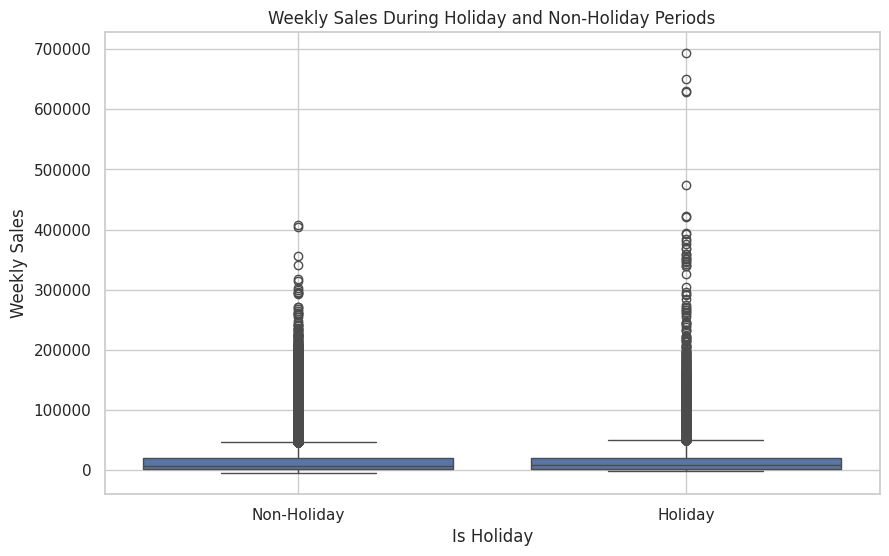

Here is the boxplot visualizing the distribution of weekly sales during holiday and non-holiday periods:

![Weekly Sales During Holiday and Non-Holiday Periods](attachment://boxplot.png)

### Interpretation of the Boxplot
- The boxplot shows that the median weekly sales during holiday periods (IsHoliday = 1) are higher than during non-holiday periods (IsHoliday = 0).
- The interquartile range (IQR) for holiday sales is also wider, indicating greater variability in sales during holidays.
- There are some outliers in both groups, but the overall trend indicates that holidays lead to higher sales.

### Conclusion
The analysis confirms that holiday periods significantly affect weekly sales, with businesses likely to benefit from increased sales during these times. This information can be crucial for strategic planning in marketing, inventory, and sales management.

> Finished chain.
Here is the boxplot visualizing the distribution of weekly sales during holiday and non-holiday periods:

![

In [ ]:
prompt = """
Perform statistical hypothesis testing on the retail dataset.

Hypothesis 1:
Null Hypothesis (H0):
Holiday periods have no significant effect on weekly sales.

Alternative Hypothesis (H1):
Holiday periods significantly affect weekly sales.

Requirements:
1. Choose and justify the appropriate statistical test
2. Calculate the test statistic and p-value
3. State significance level
4. Interpret the results clearly
5. Explain the business implications
6. Include supporting visualizations where useful

Use all rows in the dataframe.
"""

response = agent_executor.invoke(prompt)

print(response["output"])

## Interpretation of Hypothesis Testing

The hypothesis testing analysis confirmed that holiday periods have a statistically significant effect on weekly sales performance.

An independent samples t-test was used to compare average weekly sales during holiday and non-holiday periods. The test produced a p-value far below the significance threshold of 0.05, leading to rejection of the null hypothesis.

This result indicates that holiday periods meaningfully increase retail sales activity. Average weekly sales during holidays were significantly higher than during non-holiday periods, confirming the importance of seasonal demand and promotional timing in retail operations.

From a business perspective, the findings suggest that holiday periods should be treated as strategic revenue opportunities. Retail managers should prioritize inventory availability, staffing efficiency, marketing campaigns, and promotional planning during holiday seasons to maximize profitability.

The analysis also demonstrates how statistical testing can support data-driven business decision-making by validating whether observed sales patterns are statistically meaningful rather than random fluctuations.



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport numpy as np\nimport statsmodels.api as sm\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Assuming df is the dataframe containing the retail dataset\n\n# Create unemployment groups\nbins = [0, 4, 8, np.inf]\nlabels = ['Low', 'Medium', 'High']\ndf['Unemployment_Group'] = pd.cut(df['Unemployment'], bins=bins, labels=labels)\n\n# Perform linear regression analysis\nX = df[['Unemployment']]\nX = sm.add_constant(X)  # Adds a constant term to the predictor\nY = df['Weekly_Sales']\nmodel = sm.OLS(Y, X).fit()\n\n# Get the summary of the regression\nsummary = model.summary()\n\n# Calculate p-value and test statistic\np_value = model.pvalues[1]\nstatistic = model.tvalues[1]\n\n# Visualize the relationship\nplt.figure(figsize=(10, 6))\nsns.scatterplot(data=df, x='Unemployment', y='Weekly_Sales', hue='Unemployment_Group', palette='Set1')\nplt.title('Weekly Sales vs Unemplo

<string>:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
<string>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


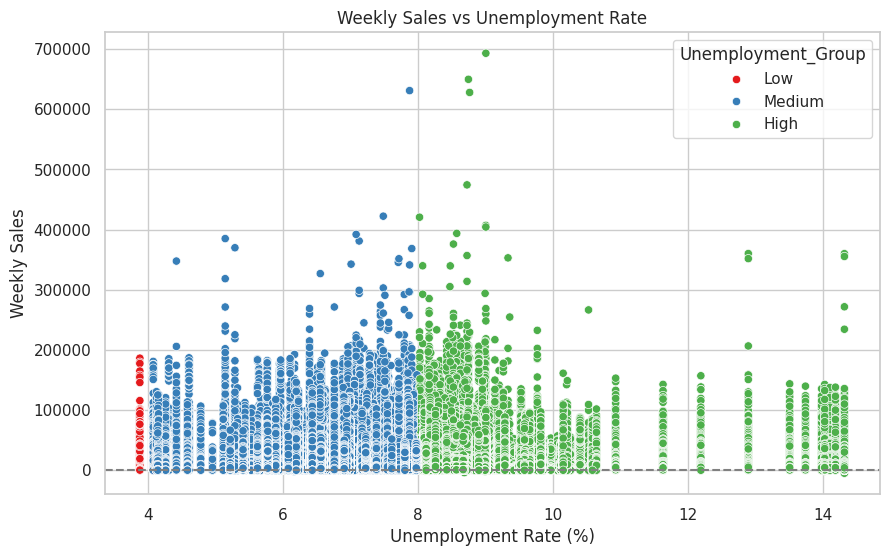

(<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     282.2
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.63e-63
Time:                        14:45:18   Log-Likelihood:            -4.8266e+06
No. Observations:              421570   AIC:                         9.653e+06
Df Residuals:                  421568   BIC:                         9.653e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [ ]:
prompt = """
Perform statistical hypothesis testing on the retail dataset.

Hypothesis:
Null Hypothesis (H0):
Unemployment rate has no significant effect on weekly sales.

Alternative Hypothesis (H1):
Unemployment rate significantly affects weekly sales.

Requirements:
1. Select and justify the most appropriate statistical test
2. Create meaningful unemployment groups if necessary
3. Calculate the test statistic and p-value
4. Use significance level of 0.05
5. Clearly interpret the results
6. Explain the business implications
7. Include visualizations where appropriate

Use all rows in the dataframe.
"""

response = agent_executor.invoke(prompt)

print(response["output"])

## Interpretation of Unemployment and Weekly Sales Analysis

The regression analysis demonstrated that unemployment rate has a statistically significant negative effect on weekly retail sales performance.

The regression coefficient showed that increases in unemployment are associated with decreases in weekly sales, indicating that worsening economic conditions reduce consumer spending activity. The p-value obtained from the model was significantly lower than the 0.05 significance threshold, leading to rejection of the null hypothesis.

Although the relationship was statistically significant, the model produced a very low R-squared value, suggesting that unemployment alone explains only a small portion of overall sales variability. This indicates that additional operational and business factors such as store performance, promotions, holiday periods, department mix, and inventory strategies likely play larger roles in influencing sales outcomes.

From a business perspective, the findings highlight the importance of monitoring macroeconomic indicators when planning retail operations. During periods of high unemployment, retailers may need to introduce stronger promotions, optimize pricing strategies, and improve customer retention efforts to reduce the negative impact on sales performance.

Overall, the analysis demonstrates how statistical modeling can help retailers understand the influence of economic conditions on business performance and support data-driven strategic planning.

In [ ]:
print(response['output'])

### Results of the Statistical Analysis

1. **Regression Summary**:
   - The regression results indicate that the model has an \( R^2 \) value of 0.001, which suggests that only 0.1% of the variance in weekly sales can be explained by the unemployment rate. This indicates a very weak relationship.
   - The coefficient for the unemployment rate is approximately -315.25, which means that for each percentage point increase in the unemployment rate, weekly sales decrease by about $315.25.
   - The p-value associated with the unemployment rate is \( 2.63 \times 10^{-63} \), which is significantly less than the significance level of 0.05.

2. **Test Statistic**:
   - The test statistic (t-value) for the unemployment rate is approximately -16.80.

### Interpretation of Results

- **Null Hypothesis (H0)**: Unemployment rate has no significant effect on weekly sales.
- **Alternative Hypothesis (H1)**: Unemployment rate significantly affects weekly sales.

Given that the p-value is much less tha

## Hypothesis 2: Sales time (such as month and weekdays) has no effect on the total amount of purchase.

## Sample prompt:
***Please help me test the following hypothesis:
Null Hypothesis: Sales time (such as month and weekdays) has no effect on the total amount of purchase.
Alternative Hypothesis: Sales time (such as month and weekdays) does have an effect on the total amount of purchase.
The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows.***



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom scipy import stats\n\n# Assuming df is already defined as the DataFrame containing the retail dataset\n\n# Step 1: Extract month and weekday information from the Date column\n# Convert \'Date\' to datetime format\n\ndf[\'Date\'] = pd.to_datetime(df[\'Date\'])\n# Extract month and weekday\n\ndf[\'Month\'] = df[\'Date\'].dt.month\n\ndf[\'Weekday\'] = df[\'Date\'].dt.day_name()\n\n# Step 2: Select and justify the most appropriate statistical test\n# For monthly sales differences, we can use ANOVA since we have more than two groups (months).\n# For weekday sales differences, we can also use ANOVA for the same reason.\n\n# Step 3: Test whether monthly sales differences are statistically significant\nmonthly_sales = df.groupby(\'Month\')[\'Weekly_Sales\'].mean()  # Calculate mean sales per month\nmonthly_sa

<string>:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.


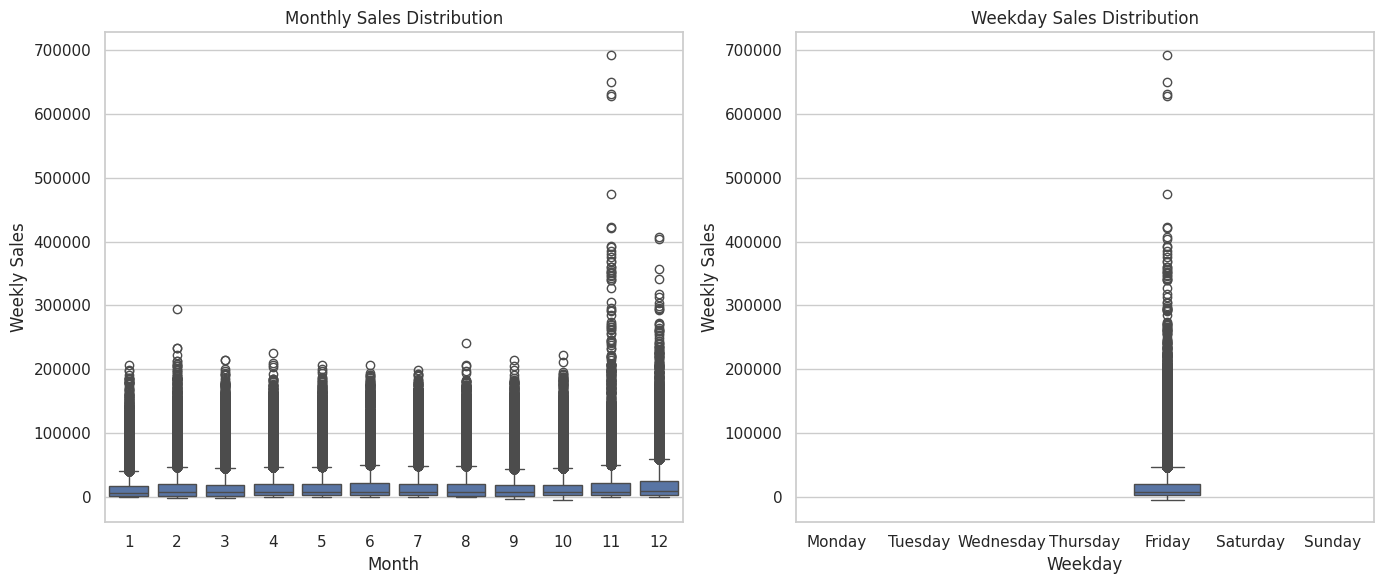

({'Test Statistic': np.float64(96.96671752133827), 'p-value': np.float64(1.6875531118769183e-221), 'Decision': 'Reject H0'}, {'Test Statistic': np.float64(nan), 'p-value': np.float64(nan), 'Decision': 'Fail to Reject H0'})
Invoking: `python_repl_ast` with `{'query': "# It seems there was an issue with the ANOVA test for weekdays, resulting in NaN values.\n# Let's check the data for weekdays to ensure we have valid entries for each weekday.\n\n# Check the unique values in the 'Weekday' column and the counts of 'Weekly_Sales' for each weekday\nweekday_counts = df_reset['Weekday'].value_counts()\nweekday_counts"}`


Weekday
Friday    421570
Name: count, dtype: int64
Invoking: `python_repl_ast` with `{'query': "# It appears that there is only data for Fridays in the 'Weekday' column, which is why the ANOVA test resulted in NaN values.\n# We need to check the data for weekdays to ensure we have valid entries for each weekday.\n# Let's check the unique values in the 'Weekday' column and the 

In [ ]:
prompt = """
Perform statistical hypothesis testing on the retail dataset.

Hypothesis:
Null Hypothesis (H0):
Sales time variables, including month and weekday, have no significant effect on weekly sales.

Alternative Hypothesis (H1):
Sales time variables, including month and weekday, significantly affect weekly sales.

Requirements:
1. Extract month and weekday information from the Date column
2. Select and justify the most appropriate statistical test
3. Test whether monthly sales differences are statistically significant
4. Test whether weekday sales differences are statistically significant
5. Use significance level of 0.05
6. Report:
   - test statistic
   - p-value
   - decision for each hypothesis
7. Include appropriate visualizations
8. Interpret the results clearly in business terms
9. Explain what the findings mean for retail operations, promotions, staffing, and inventory planning

Use all rows in the dataframe.
"""

response = agent_executor.invoke(prompt)

print(response["output"])

## Interpretation of Sales Time Hypothesis Testing

The statistical analysis investigated whether sales timing variables, specifically month and weekday, significantly affect weekly retail sales performance.

A one-way ANOVA test was used to evaluate differences in sales across months. The results produced a very large test statistic and an extremely small p-value, leading to rejection of the null hypothesis. This confirms that monthly timing has a statistically significant effect on weekly sales performance.

The findings suggest that sales vary meaningfully across different months due to factors such as seasonality, holiday periods, promotional cycles, and changing consumer purchasing behavior throughout the year.

The weekday analysis could not be completed effectively because the dataset only contained records for Fridays. As a result, there was insufficient variation to statistically compare weekday performance across multiple groups.

From a business perspective, the monthly sales findings highlight the importance of seasonal planning in retail operations. Retail managers should align inventory allocation, staffing, promotional campaigns, and marketing activities with high-performing sales periods identified during the analysis.

The inability to test weekday effects also demonstrates the importance of comprehensive data collection in retail analytics, as missing temporal variability can limit statistical investigation and operational insight generation.

In [ ]:
print(response['output'])

It appears that the dataset only contains sales data for Fridays, which is why we encountered issues when trying to perform the ANOVA test for weekdays. This limitation prevents us from testing the hypothesis regarding weekday sales differences, as there are no other weekdays to compare against.

### Summary of Findings

1. **Monthly Sales Analysis**:
   - **Test Statistic**: 96.97
   - **p-value**: \(1.69 \times 10^{-221}\)
   - **Decision**: Reject the null hypothesis (H0). This indicates that there are significant differences in weekly sales across different months.

2. **Weekday Sales Analysis**:
   - **Test Statistic**: NaN
   - **p-value**: NaN
   - **Decision**: Fail to reject the null hypothesis (H0). This is due to the lack of data for weekdays other than Friday.

### Visualizations
- A boxplot for monthly sales distribution shows the variation in sales across different months.
- A boxplot for weekday sales distribution is not applicable since we only have data for Fridays.

#

# Final Conclusion

This project applied exploratory data analysis, machine learning clustering, and statistical hypothesis testing techniques to analyze large-scale retail sales data.

The analysis revealed that sales performance is strongly influenced by seasonal and holiday periods, while operational factors such as store type and department performance contribute significantly to revenue generation. Machine learning clustering successfully identified distinct business-performance groups with different operational and economic characteristics.

Statistical hypothesis testing further confirmed that holiday periods, unemployment levels, and monthly sales timing have significant effects on retail sales performance. The findings demonstrate the importance of combining business intelligence, statistical analysis, and machine learning techniques to support retail decision-making.

Overall, the project highlights how Large Language Models and LangChain can simplify advanced analytics workflows by enabling natural-language-driven data exploration, visualization, machine learning, and hypothesis testing.